In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import json
import random
from dotenv import load_dotenv

from pydrake.all import (
    StartMeshcat,
    DiagramBuilder,
    Parser,
    ProcessModelDirectives,
    LoadModelDirectives,
    MultibodyPlant,
    SceneGraph,
    Simulator,
    RigidTransform,
)
from manipulation.station import LoadScenario, MakeHardwareStation

import openai

## Set up OpenAI API Key

The API key is loaded from a `.env` file in the project root. 

**Setup Instructions:**
1. Copy `.env.example` to `.env` in the project root
2. Edit `.env` and replace `your-api-key-here` with your actual OpenAI API key
3. The `.env` file is automatically ignored by git for security

In [2]:
# Load environment variables from .env file
load_dotenv(dotenv_path='../.env')

# Get OpenAI API key from environment
openai.api_key = os.getenv('OPENAI_API_KEY')

if not openai.api_key:
    print("❌ Error: OPENAI_API_KEY not found!")
    print("\nSetup instructions:")
    print("1. Copy .env.example to .env in the project root")
    print("2. Edit .env and add your OpenAI API key")
    print("3. Restart the notebook kernel")
else:
    print("✓ OpenAI API key loaded successfully")

✓ OpenAI API key loaded successfully


## Load Real Kitchen Scene with Drake

Load the kitchen environment using Drake's scenario and extract fruit positions.

In [42]:
# Set up paths
KITCHEN_MODEL_PATH = os.path.abspath("../kitchen_model")
ASSETS_PATH = os.path.abspath("../assets")

# Set environment variables for path substitution
os.environ['KITCHEN_MODEL_PATH'] = KITCHEN_MODEL_PATH
os.environ['ASSETS_PATH'] = ASSETS_PATH

# Start meshcat for visualization
meshcat = StartMeshcat()
print(f"Meshcat listening at {meshcat.web_url()}")

# Load scenario with path substitution
scenario_file = f"{KITCHEN_MODEL_PATH}/real_kitchen_scenario.yaml"

# Read and replace placeholders in the scenario file
with open(scenario_file, 'r') as f:
    scenario_text = f.read()

scenario_text = scenario_text.replace("{KITCHEN_MODEL_PATH}", KITCHEN_MODEL_PATH)
scenario_text = scenario_text.replace("{ASSETS_PATH}", ASSETS_PATH)

# Write to temporary file
import tempfile
with tempfile.NamedTemporaryFile(mode='w', suffix='.yaml', delete=False) as tmp:
    tmp.write(scenario_text)
    tmp_scenario_file = tmp.name

scenario = LoadScenario(filename=tmp_scenario_file)

# Create the station
station = MakeHardwareStation(scenario, meshcat)
plant = station.GetSubsystemByName("plant")
scene_graph = station.GetSubsystemByName("scene_graph")

# Clean up temp file
os.unlink(tmp_scenario_file)

print(f"✓ Loaded plant with {plant.num_bodies()} bodies")

# Run physics simulation to let fruits fall and settle
print("\nSimulating physics to let fruits settle...")
sim_temp = Simulator(station)
sim_temp.Initialize()

# Get the settled positions from the simulation
context = sim_temp.get_context()
plant_context = plant.GetMyContextFromRoot(context)

# Initialize robot at the starting position with straight arm configuration
print("\n📍 Initializing robot configuration...")
try:
    # Get the mobile_iiwa model instance
    mobile_iiwa = plant.GetModelInstanceByName("mobile_iiwa")
    num_positions = plant.num_positions(mobile_iiwa)
    
    print(f"mobile_iiwa has {num_positions} DOFs")
    
    # Robot starting position
    robot_start_x = -4.0
    robot_start_y = 0.0
    
    # Get joint indices
    base_x_joint = plant.GetJointByName("iiwa_base_x", mobile_iiwa)
    base_y_joint = plant.GetJointByName("iiwa_base_y", mobile_iiwa)
    base_z_joint = plant.GetJointByName("iiwa_base_z", mobile_iiwa)
    
    base_x_idx = base_x_joint.position_start()
    base_y_idx = base_y_joint.position_start()
    base_z_idx = base_z_joint.position_start()
    
    # Create position array for mobile_iiwa only (doesn't affect fruits!)
    robot_positions = np.zeros(num_positions)
    robot_positions[base_x_idx] = robot_start_x
    robot_positions[base_y_idx] = robot_start_y
    robot_positions[base_z_idx] = 0.1  # Height
    # All arm joints default to 0 (straight configuration)
    
    # Set only the robot positions (fruits are separate model instances)
    plant.SetPositions(plant_context, mobile_iiwa, robot_positions)
    
    # Force visualization update
    station.ForcedPublish(context)
    
    print(f"✓ Robot initialized:")
    print(f"   Base position: ({robot_start_x}, {robot_start_y}, 0.1)")
    print(f"   All arm joints: 0 (straight configuration)")
        
except Exception as e:
    print(f"⚠ Could not initialize robot configuration: {e}")
    print("  Continuing with default configuration...")

# Extract fruit positions
fruits = ['apple', 'banana', 'lemon', 'orange', 'peach']
kitchen_map = {}

for fruit_name in fruits:
    try:
        model_instance = plant.GetModelInstanceByName(fruit_name)
        body_name = fruit_name + '_link'
        body = plant.GetBodyByName(body_name, model_instance)
        pose = plant.EvalBodyPoseInWorld(plant_context, body)
        position = pose.translation()
        
        kitchen_map[fruit_name] = {
            'position': position.tolist(),
            'x': float(position[0]),
            'y': float(position[1]),
            'z': float(position[2])
        }
        
        print(f"{fruit_name}: {position}")
    except Exception as e:
        print(f"⚠️ Could not find {fruit_name}: {e}")

print(f"\n✓ Kitchen map created with {len(kitchen_map)} fruits")
print("\nKitchen Map:")
print(json.dumps(kitchen_map, indent=2))

INFO:drake:Meshcat listening for connections at http://localhost:7002


Meshcat listening at http://localhost:7002


✓ Loaded plant with 29 bodies

Simulating physics to let fruits settle...

📍 Initializing robot configuration...
mobile_iiwa has 10 DOFs
✓ Robot initialized:
   Base position: (-4.0, 0.0, 0.1)
   All arm joints: 0 (straight configuration)
apple: [-4.5  -1.5   0.95]
banana: [-5.7  -2.    0.95]
lemon: [-4.3  -3.15  0.95]
orange: [-5.3  -2.    0.95]
peach: [-5.4  -3.15  0.95]

✓ Kitchen map created with 5 fruits

Kitchen Map:
{
  "apple": {
    "position": [
      -4.5,
      -1.5,
      0.95
    ],
    "x": -4.5,
    "y": -1.5,
    "z": 0.95
  },
  "banana": {
    "position": [
      -5.7,
      -2.0,
      0.95
    ],
    "x": -5.7,
    "y": -2.0,
    "z": 0.95
  },
  "lemon": {
    "position": [
      -4.3,
      -3.15,
      0.95
    ],
    "x": -4.3,
    "y": -3.15,
    "z": 0.95
  },
  "orange": {
    "position": [
      -5.3,
      -2.0,
      0.95
    ],
    "x": -5.3,
    "y": -2.0,
    "z": 0.95
  },
  "peach": {
    "position": [
      -5.4,
      -3.15,
      0.95
    ],
    "

## GPT-4o Query Function

Create a function to query GPT-4o with manipulation commands.

In [4]:
class RRTPlanner:
    """RRT path planner using occupancy grid for collision checking."""
    
    def __init__(self, grid_info, step_size=0.3, max_iterations=5000, goal_sample_rate=0.1):
        self.occupancy_grid = grid_info['occupancy_grid']
        self.x_positions = grid_info['x_positions']
        self.y_positions = grid_info['y_positions']
        self.resolution = grid_info['resolution']
        self.bounds = grid_info['bounds']
        self.x_min, self.x_max, self.y_min, self.y_max = self.bounds
        
        self.step_size = step_size
        self.max_iterations = max_iterations
        self.goal_sample_rate = goal_sample_rate
        
    def is_collision_free(self, x, y):
        """Check if a point is collision-free using occupancy grid."""
        i = int((x - self.x_min) / self.resolution)
        j = int((y - self.y_min) / self.resolution)
        
        if i < 0 or i >= self.occupancy_grid.shape[1] or j < 0 or j >= self.occupancy_grid.shape[0]:
            return False
        
        return self.occupancy_grid[j, i] == 0
    
    def is_path_collision_free(self, p1, p2, num_checks=20):
        """Check if a straight line path between two points is collision-free."""
        for i in range(num_checks + 1):
            t = i / num_checks
            x = p1[0] + t * (p2[0] - p1[0])
            y = p1[1] + t * (p2[1] - p1[1])
            
            if not self.is_collision_free(x, y):
                return False
        
        return True
    
    def sample_random_point(self):
        """Sample a random point in the search space."""
        x = random.uniform(self.x_min, self.x_max)
        y = random.uniform(self.y_min, self.y_max)
        return np.array([x, y])
    
    def get_nearest_node(self, tree, point):
        """Find the nearest node in the tree to the given point."""
        if len(tree) == 0:
            return None
        
        distances = [np.linalg.norm(node - point) for node in tree]
        return np.argmin(distances)
    
    def steer(self, from_point, to_point):
        """Steer from from_point toward to_point by at most step_size."""
        direction = to_point - from_point
        distance = np.linalg.norm(direction)
        
        if distance <= self.step_size:
            return to_point
        else:
            return from_point + (direction / distance) * self.step_size
    
    def plan(self, start, goal):
        """Plan a path from start to goal using RRT."""
        start = np.array(start)
        goal = np.array(goal)
        
        if not self.is_collision_free(start[0], start[1]):
            print(f"Start position {start} is in collision!")
            return None
        
        if not self.is_collision_free(goal[0], goal[1]):
            print(f"Goal position {goal} is in collision!")
            return None
        
        tree = [start]
        parent = {0: None}
        
        for iteration in range(self.max_iterations):
            if random.random() < self.goal_sample_rate:
                sample = goal
            else:
                sample = self.sample_random_point()
            
            nearest_idx = self.get_nearest_node(tree, sample)
            nearest = tree[nearest_idx]
            
            new_point = self.steer(nearest, sample)
            
            if self.is_path_collision_free(nearest, new_point):
                new_idx = len(tree)
                tree.append(new_point)
                parent[new_idx] = nearest_idx
                
                if np.linalg.norm(new_point - goal) < self.step_size:
                    if self.is_path_collision_free(new_point, goal):
                        goal_idx = len(tree)
                        tree.append(goal)
                        parent[goal_idx] = new_idx
                        
                        path = []
                        current = goal_idx
                        while current is not None:
                            path.append(tuple(tree[current]))
                            current = parent[current]
                        
                        path.reverse()
                        return path
        
        print(f"RRT failed to find path after {self.max_iterations} iterations")
        return None

print("✓ RRT planner class defined")

✓ RRT planner class defined


In [5]:
from scipy.spatial import KDTree
from scipy.ndimage import zoom, binary_dilation

# Load pre-computed occupancy grid
print("Loading pre-computed 2D occupancy grid...")
data_dir = Path('../data')

occupancy_grid_full = np.load(data_dir / 'kitchen_occupancy_grid.npy')
metadata = np.load(data_dir / 'kitchen_occupancy_grid_metadata.npy', allow_pickle=True).item()

grid_resolution = metadata.get('resolution', 0.1)
WAYPOINT_SPACING = 0.1

# Define bounds
X_MIN, X_MAX = -7.7, -2.7
Y_MIN, Y_MAX = -3.0, 1.0

# Crop grid to bounds
orig_x_min = metadata.get('x_min', -11.0)
orig_x_max = metadata.get('x_max', 1.0)
orig_y_min = metadata.get('y_min', -6.0)
orig_y_max = metadata.get('y_max', 6.0)

orig_x_positions = np.arange(orig_x_min, orig_x_max, grid_resolution)
orig_y_positions = np.arange(orig_y_min, orig_y_max, grid_resolution)

x_start_idx = np.searchsorted(orig_x_positions, X_MIN)
x_end_idx = np.searchsorted(orig_x_positions, X_MAX)
y_start_idx = np.searchsorted(orig_y_positions, Y_MIN)
y_end_idx = np.searchsorted(orig_y_positions, Y_MAX)

occupancy_grid = occupancy_grid_full[y_start_idx:y_end_idx, x_start_idx:x_end_idx]

# Resample if needed
if abs(grid_resolution - WAYPOINT_SPACING) > 0.01:
    scale_factor = grid_resolution / WAYPOINT_SPACING
    occupancy_grid = zoom(occupancy_grid, scale_factor, order=0).astype(np.uint8)

x_positions = np.arange(X_MIN, X_MAX, WAYPOINT_SPACING)
y_positions = np.arange(Y_MIN, Y_MAX, WAYPOINT_SPACING)

# Apply dilation to expand obstacles (account for robot arm size)
ROBOT_RADIUS = 0.2  # meters - safety margin around obstacles
dilation_cells = int(ROBOT_RADIUS / WAYPOINT_SPACING)

print(f"\nApplying safety margin to occupancy grid...")
print(f"  Robot safety radius: {ROBOT_RADIUS}m")
print(f"  Dilation: {dilation_cells} cells ({dilation_cells * WAYPOINT_SPACING:.2f}m)")

occupancy_grid_original = occupancy_grid.copy()
structure = np.ones((dilation_cells*2+1, dilation_cells*2+1))
occupancy_grid = binary_dilation(occupancy_grid > 0, structure=structure).astype(np.uint8)

print(f"  Original free cells: {np.sum(occupancy_grid_original == 0)}")
print(f"  Dilated free cells: {np.sum(occupancy_grid == 0)}")
print(f"  Reduction: {np.sum(occupancy_grid_original == 0) - np.sum(occupancy_grid == 0)} cells")

# Store grid info
grid_info = {
    'occupancy_grid': occupancy_grid,
    'x_positions': x_positions,
    'y_positions': y_positions,
    'resolution': WAYPOINT_SPACING,
    'bounds': (X_MIN, X_MAX, Y_MIN, Y_MAX)
}

print(f"\n✓ Occupancy grid loaded and dilated: {occupancy_grid.shape}")

# Create RRT planner
rrt = RRTPlanner(grid_info, step_size=0.3, max_iterations=5000, goal_sample_rate=0.15)
print("✓ RRT planner created")

Loading pre-computed 2D occupancy grid...

Applying safety margin to occupancy grid...
  Robot safety radius: 0.2m
  Dilation: 2 cells (0.20m)
  Original free cells: 1207
  Dilated free cells: 713
  Reduction: 494 cells

✓ Occupancy grid loaded and dilated: (40, 50)
✓ RRT planner created


## Diagnose Path Planning Issues

Check robot start position and connectivity.

In [6]:

print("="*60)
print("🔍 DETAILED PATH PLANNING DIAGNOSIS")
print("="*60)

robot_start = (-4.0, 0.0)

print(f"\n1. Robot Start: {robot_start}")
is_start_free = rrt.is_collision_free(robot_start[0], robot_start[1])
print(f"   Collision-free: {is_start_free}")

if not is_start_free:
    print("\n   ❌ PROBLEM FOUND: Robot start is in COLLISION!")
    print("   📍 Solution: Change robot start position")
else:
    print("   ✓ Robot start is FREE")

# 2. 检查目标位置
try:
    manipulation_result
    has_result = True
except NameError:
    has_result = False
    print("\n⚠️  Note: manipulation_result not yet defined (run the planning cell first)")

if has_result and manipulation_result:
    pickup_pos = manipulation_result.get('pickup_pos')
    dropoff_pos = manipulation_result.get('dropoff_pos')
    
    if pickup_pos:
        print(f"\n2. Pickup Position: {pickup_pos}")
        is_pickup_free = rrt.is_collision_free(pickup_pos[0], pickup_pos[1])
        print(f"   Collision-free: {is_pickup_free}")
        
        if not is_pickup_free:
            print("   ❌ PROBLEM: Pickup position in collision!")
    
    if dropoff_pos:
        print(f"\n3. Drop-off Position: {dropoff_pos}")
        is_dropoff_free = rrt.is_collision_free(dropoff_pos[0], dropoff_pos[1])
        print(f"   Collision-free: {is_dropoff_free}")
        
        if not is_dropoff_free:
            print("   ❌ PROBLEM: Drop-off position in collision!")

print(f"\n4. Testing RRT sampling from robot start...")
print(f"   Trying to sample 20 random points and check reachability...")

test_reached = 0
for i in range(20):
    sample = rrt.sample_random_point()
    if rrt.is_collision_free(sample[0], sample[1]):
        if rrt.is_path_collision_free(robot_start, sample):
            test_reached += 1

print(f"   ✓ Could reach {test_reached}/20 random free points from robot start")

if test_reached == 0:
    print("\n   ❌ CRITICAL PROBLEM: Robot start is ISOLATED!")
    print("   机器人起始位置与其他可通行区域完全断开！")
    print("\n   🔧 Solutions:")
    print("   Option 1: 减小 ROBOT_RADIUS (当前: 0.15m)")
    print("   Option 2: 改变机器人起始位置到确认可通行的区域")
    
    print("\n   🎯 Suggested robot start positions:")
    test_positions = [
        (-6.0, -2.5),  # 左下方中心区域
        (-5.5, -1.5),  # banana附近
        (-6.5, 0.0),   # 左侧中部
    ]
    
    for test_pos in test_positions:
        if rrt.is_collision_free(test_pos[0], test_pos[1]):
            # 测试能否从这里到达一些目标
            can_reach = 0
            for _ in range(5):
                sample = rrt.sample_random_point()
                if rrt.is_collision_free(sample[0], sample[1]):
                    if rrt.is_path_collision_free(test_pos, sample):
                        can_reach += 1
            
            print(f"   • {test_pos}: FREE, can reach {can_reach}/5 samples")

# 5. 检查occupancy grid的具体值
i_robot = int((robot_start[0] - X_MIN) / WAYPOINT_SPACING)
j_robot = int((robot_start[1] - Y_MIN) / WAYPOINT_SPACING)

print(f"\n5. Occupancy Grid Detail at Robot Start:")
print(f"   Grid indices: ({i_robot}, {j_robot})")
if 0 <= i_robot < occupancy_grid.shape[1] and 0 <= j_robot < occupancy_grid.shape[0]:
    print(f"   Grid value: {occupancy_grid[j_robot, i_robot]}")
    print(f"   (0=free, 1=occupied)")
    
    # 检查周围
    print(f"\n   Surrounding cells (3x3):")
    for dj in range(-1, 2):
        row = ""
        for di in range(-1, 2):
            ii = i_robot + di
            jj = j_robot + dj
            if 0 <= ii < occupancy_grid.shape[1] and 0 <= jj < occupancy_grid.shape[0]:
                row += f"{occupancy_grid[jj, ii]} "
            else:
                row += "X "
        print(f"   {row}")
else:
    print(f"   ❌ Robot start is OUTSIDE grid bounds!")

print("\n" + "="*60)

🔍 DETAILED PATH PLANNING DIAGNOSIS

1. Robot Start: (-4.0, 0.0)
   Collision-free: True
   ✓ Robot start is FREE

⚠️  Note: manipulation_result not yet defined (run the planning cell first)

4. Testing RRT sampling from robot start...
   Trying to sample 20 random points and check reachability...
   ✓ Could reach 3/20 random free points from robot start

5. Occupancy Grid Detail at Robot Start:
   Grid indices: (37, 30)
   Grid value: 0
   (0=free, 1=occupied)

   Surrounding cells (3x3):
   0 0 0 
   0 0 0 
   0 0 0 



## Load Occupancy Grid and Setup RRT Planner

Load the pre-computed occupancy grid and create an RRT planner for navigation.

In [7]:
def query_gpt_for_manipulation(command: str, kitchen_map: dict) -> dict:
    """
    Query GPT-4o-mini to interpret a manipulation command and identify the object and target.
    
    Args:
        command: Natural language command (e.g., "Put apple beside the banana")
        kitchen_map: Dictionary mapping fruit names to their positions
    
    Returns:
        Dictionary with 'object', 'target_object', and 'relationship' keys
    """
    
    # Create the prompt for GPT-4o-mini
    prompt = f"""You are a robotic manipulation assistant. Given a kitchen map with fruit positions and a manipulation command, determine:
1. Which object to manipulate (object_to_move)
2. The target/reference object (target_object)
3. The spatial relationship (e.g., "beside", "next to", "near")

Kitchen Map (available objects):
{json.dumps(list(kitchen_map.keys()), indent=2)}

Command: {command}

Respond ONLY with a valid JSON object in this exact format:
{{
    "object_to_move": "name_of_object_to_move",
    "target_object": "name_of_reference_object",
    "relationship": "beside|next_to|near",
    "reasoning": "brief explanation"
}}

Example: For "Put apple beside the banana", respond with:
{{
    "object_to_move": "apple",
    "target_object": "banana",
    "relationship": "beside",
    "reasoning": "Move apple to be beside banana"
}}
"""

    try:
        # Call GPT-4o-mini API (new OpenAI v1.0+ syntax)
        from openai import OpenAI
        client = OpenAI(api_key=openai.api_key)
        
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "You are a robotic manipulation expert. Always respond with valid JSON. Only identify objects and relationships, do not calculate positions."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.3,
            max_tokens=300
        )
        
        # Extract and parse the response
        response_text = response.choices[0].message.content.strip()
        
        # Remove code blocks if present
        if response_text.startswith('```'):
            response_text = response_text.split('```')[1]
            if response_text.startswith('json'):
                response_text = response_text[4:]
            response_text = response_text.strip()
        
        result = json.loads(response_text)
        
        return result
        
    except Exception as e:
        print(f"❌ Error querying GPT-4o-mini: {e}")
        return None

def calculate_target_position(object_pos, target_pos, relationship="beside"):
    """
    Calculate the target position based on the relationship to the reference object.
    Uses 2D grid-based planning.
    
    Args:
        object_pos: Current position [x, y, z] of object to move
        target_pos: Position [x, y, z] of reference object
        relationship: Spatial relationship ("beside", "next_to", "near")
    
    Returns:
        Target position [x, y, z]
    """
    # For "beside"/"next to"/"near", place object approximately 0.15-0.2m away
    offset_distance = 0.18
    
    # Keep same z-coordinate (height) as target object
    target_z = target_pos[2]
    
    # Place to the right of target object (positive x direction)
    target_x = target_pos[0] + offset_distance
    target_y = target_pos[1]
    
    return [target_x, target_y, target_z]

print("✓ GPT-4o-mini query function and position calculation defined")


✓ GPT-4o-mini query function and position calculation defined


## Test: Put Apple Beside Banana

In [8]:
# Test the manipulation command with navigation
command = "Put apple beside the banana"
# command = "Put banana beside the orange"

print(f"Command: {command}\n")

# Step 1: Get object identification from GPT
gpt_result = query_gpt_for_manipulation(command, kitchen_map)

if gpt_result:
    print("\n✓ GPT-4o Response:")
    print(json.dumps(gpt_result, indent=2))
    
    # Step 2: Get actual positions from kitchen map
    object_to_move = gpt_result['object_to_move']
    target_object = gpt_result['target_object']
    
    if object_to_move not in kitchen_map:
        print(f"❌ Error: '{object_to_move}' not found in kitchen map")
        manipulation_result = None
    elif target_object not in kitchen_map:
        print(f"❌ Error: '{target_object}' not found in kitchen map")
        manipulation_result = None
    else:
        object_pos = kitchen_map[object_to_move]['position']
        target_pos = kitchen_map[target_object]['position']
        
        # Step 3: Calculate target position using grid-based method
        relationship = gpt_result.get('relationship', 'beside')
        end_position = calculate_target_position(object_pos, target_pos, relationship)
        
        print("\n" + "="*60)
        print("MANIPULATION TASK")
        print("="*60)
        print(f"Object to move: {object_to_move}")
        print(f"Target object:  {target_object}")
        print(f"Relationship:   {relationship}")
        print(f"Start position (current): {object_pos}")
        print(f"End position (calculated): {end_position}")
        print(f"Reasoning: {gpt_result.get('reasoning', 'N/A')}")
        print("="*60)
        
        # Step 4: Find nearest free waypoints if positions are in collision
        print("\n" + "="*60)
        print("COLLISION CHECKING & WAYPOINT ADJUSTMENT")
        print("="*60)
        
        # Generate free waypoints for nearest neighbor search
        free_waypoints = []
        for i, x in enumerate(x_positions):
            for j, y in enumerate(y_positions):
                if occupancy_grid[j, i] == 0:
                    free_waypoints.append((x, y))
        free_waypoints = np.array(free_waypoints)
        
        from scipy.spatial import KDTree
        kdtree = KDTree(free_waypoints)
        
        # Check pickup position
        pickup_pos_original = (object_pos[0], object_pos[1])
        pickup_is_free = rrt.is_collision_free(pickup_pos_original[0], pickup_pos_original[1])
        
        if not pickup_is_free:
            # Find nearest TRULY collision-free waypoint
            distances, indices = kdtree.query(pickup_pos_original, k=min(50, len(free_waypoints)))
            pickup_pos = None
            for dist, idx in zip(distances, indices):
                candidate = tuple(free_waypoints[idx])
                if rrt.is_collision_free(candidate[0], candidate[1]):
                    pickup_pos = candidate
                    print(f"⚠ Pickup position {pickup_pos_original} is in collision!")
                    print(f"  Using nearest VERIFIED free waypoint: {pickup_pos} (distance: {dist:.3f}m)")
                    break
            
            if pickup_pos is None:
                print(f"❌ ERROR: Could not find collision-free waypoint near {pickup_pos_original}!")
                pickup_pos = pickup_pos_original  # Fallback
        else:
            pickup_pos = pickup_pos_original
            print(f"✓ Pickup position {pickup_pos} is collision-free")
        
        # Check dropoff position
        dropoff_pos_original = (end_position[0], end_position[1])
        dropoff_is_free = rrt.is_collision_free(dropoff_pos_original[0], dropoff_pos_original[1])
        
        if not dropoff_is_free:
            # Find nearest TRULY collision-free waypoint
            distances, indices = kdtree.query(dropoff_pos_original, k=min(50, len(free_waypoints)))
            dropoff_pos = None
            for dist, idx in zip(distances, indices):
                candidate = tuple(free_waypoints[idx])
                if rrt.is_collision_free(candidate[0], candidate[1]):
                    dropoff_pos = candidate
                    print(f"⚠ Drop-off position {dropoff_pos_original} is in collision!")
                    print(f"  Using nearest VERIFIED free waypoint: {dropoff_pos} (distance: {dist:.3f}m)")
                    break
            
            if dropoff_pos is None:
                print(f"❌ ERROR: Could not find collision-free waypoint near {dropoff_pos_original}!")
                dropoff_pos = dropoff_pos_original  # Fallback
        else:
            dropoff_pos = dropoff_pos_original
            print(f"✓ Drop-off position {dropoff_pos} is collision-free")
        
        print("="*60)
        
        # Step 5: Plan navigation paths using 2D grid
        print("\n" + "="*60)
        print("NAVIGATION PLANNING (2D Grid-based RRT)")
        print("="*60)
        
        # Robot starts at initial position
        robot_start = (-4.0, 0.0)  # Initial robot position
        
        print(f"\nRobot start: {robot_start}")
        print(f"Pickup waypoint ({object_to_move}): {pickup_pos}")
        print(f"Drop-off waypoint (beside {target_object}): {dropoff_pos}")
        
        # Plan path 1: Robot start -> Pickup location (using 2D grid)
        print(f"\n📍 Planning path 1: Robot → {object_to_move} pickup waypoint...")
        path_to_pickup = rrt.plan(robot_start, pickup_pos)
        
        if path_to_pickup:
            print(f"✓ Path found with {len(path_to_pickup)} waypoints")
        else:
            print("❌ Failed to find path to pickup location")
        
        # Plan path 2: Pickup location -> Drop-off location (using 2D grid)
        print(f"\n📍 Planning path 2: Pickup waypoint → Drop-off waypoint (beside {target_object})...")
        path_to_dropoff = rrt.plan(pickup_pos, dropoff_pos)
        
        if path_to_dropoff:
            print(f"✓ Path found with {len(path_to_dropoff)} waypoints")
        else:
            print("❌ Failed to find path to drop-off location")
        
        # Store results for visualization
        manipulation_result = {
            'gpt_response': gpt_result,
            'object_to_move': object_to_move,
            'target_object': target_object,
            'start_position': object_pos,
            'end_position': end_position,
            'robot_start': robot_start,
            'pickup_pos': pickup_pos,
            'pickup_pos_original': pickup_pos_original,
            'pickup_adjusted': not pickup_is_free,
            'dropoff_pos': dropoff_pos,
            'dropoff_pos_original': dropoff_pos_original,
            'dropoff_adjusted': not dropoff_is_free,
            'path_to_pickup': path_to_pickup,
            'path_to_dropoff': path_to_dropoff
        }
        
        print("\n" + "="*60)
        if path_to_pickup and path_to_dropoff:
            total_waypoints = len(path_to_pickup) + len(path_to_dropoff) - 1  # -1 for duplicate
            print(f"✓ Complete navigation plan ready!")
            print(f"  Total waypoints: {total_waypoints}")
            print(f"  Method: 2D occupancy grid with RRT + nearest waypoint adjustment")
        else:
            print("⚠ Navigation planning incomplete")
        print("="*60)
    
else:
    print("❌ Failed to get response from GPT-4o")
    manipulation_result = None


Command: Put apple beside the banana


✓ GPT-4o Response:
{
  "object_to_move": "apple",
  "target_object": "banana",
  "relationship": "beside",
  "reasoning": "Move apple to be beside banana"
}

MANIPULATION TASK
Object to move: apple
Target object:  banana
Relationship:   beside
Start position (current): [-4.5, -1.5, 0.95]
End position (calculated): [-5.5200000000000005, -2.0, 0.95]
Reasoning: Move apple to be beside banana

COLLISION CHECKING & WAYPOINT ADJUSTMENT
⚠ Pickup position (-4.5, -1.5) is in collision!
  Using nearest VERIFIED free waypoint: (np.float64(-4.100000000000013), np.float64(-1.4999999999999987)) (distance: 0.400m)
⚠ Drop-off position (-5.5200000000000005, -2.0) is in collision!
  Using nearest VERIFIED free waypoint: (np.float64(-5.500000000000008), np.float64(-2.4999999999999996)) (distance: 0.500m)

NAVIGATION PLANNING (2D Grid-based RRT)

Robot start: (-4.0, 0.0)
Pickup waypoint (apple): (np.float64(-4.100000000000013), np.float64(-1.4999999999999987))
Drop-o

## Visualize All Available Waypoints

Show all free waypoints on the occupancy grid to understand the navigable space.


Total free waypoints: 658
Grid dimensions: (40, 50)
Total grid cells: 2000
Occupied cells: 1287
Free cells (grid check): 713
Free cells (verified): 658

NEAREST FREE WAYPOINTS TO EACH FRUIT
apple     : (-4.5, -1.5) [✗ COLLISION]
           Nearest waypoint: (np.float64(-4.100000000000013), np.float64(-1.4999999999999987)) (distance: 0.400m)
banana    : (-5.7, -2.0) [✗ COLLISION]
           Nearest waypoint: (np.float64(-5.700000000000007), np.float64(-2.4999999999999996)) (distance: 0.500m)
lemon     : (-4.3, -3.15) [✗ COLLISION]
           Nearest waypoint: (np.float64(-4.300000000000012), np.float64(-2.6999999999999997)) (distance: 0.450m)
orange    : (-5.3, -2.0) [✗ COLLISION]
           Nearest waypoint: (np.float64(-5.300000000000009), np.float64(-2.4999999999999996)) (distance: 0.500m)
peach     : (-5.4, -3.15) [✗ COLLISION]
           Nearest waypoint: (np.float64(-5.400000000000008), np.float64(-2.6999999999999997)) (distance: 0.450m)


/var/folders/26/txjfqjd52svf9l_j4txvmyc40000gn/T/ipykernel_37794/3646705558.py:89: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, s=300, c=color, marker=marker,


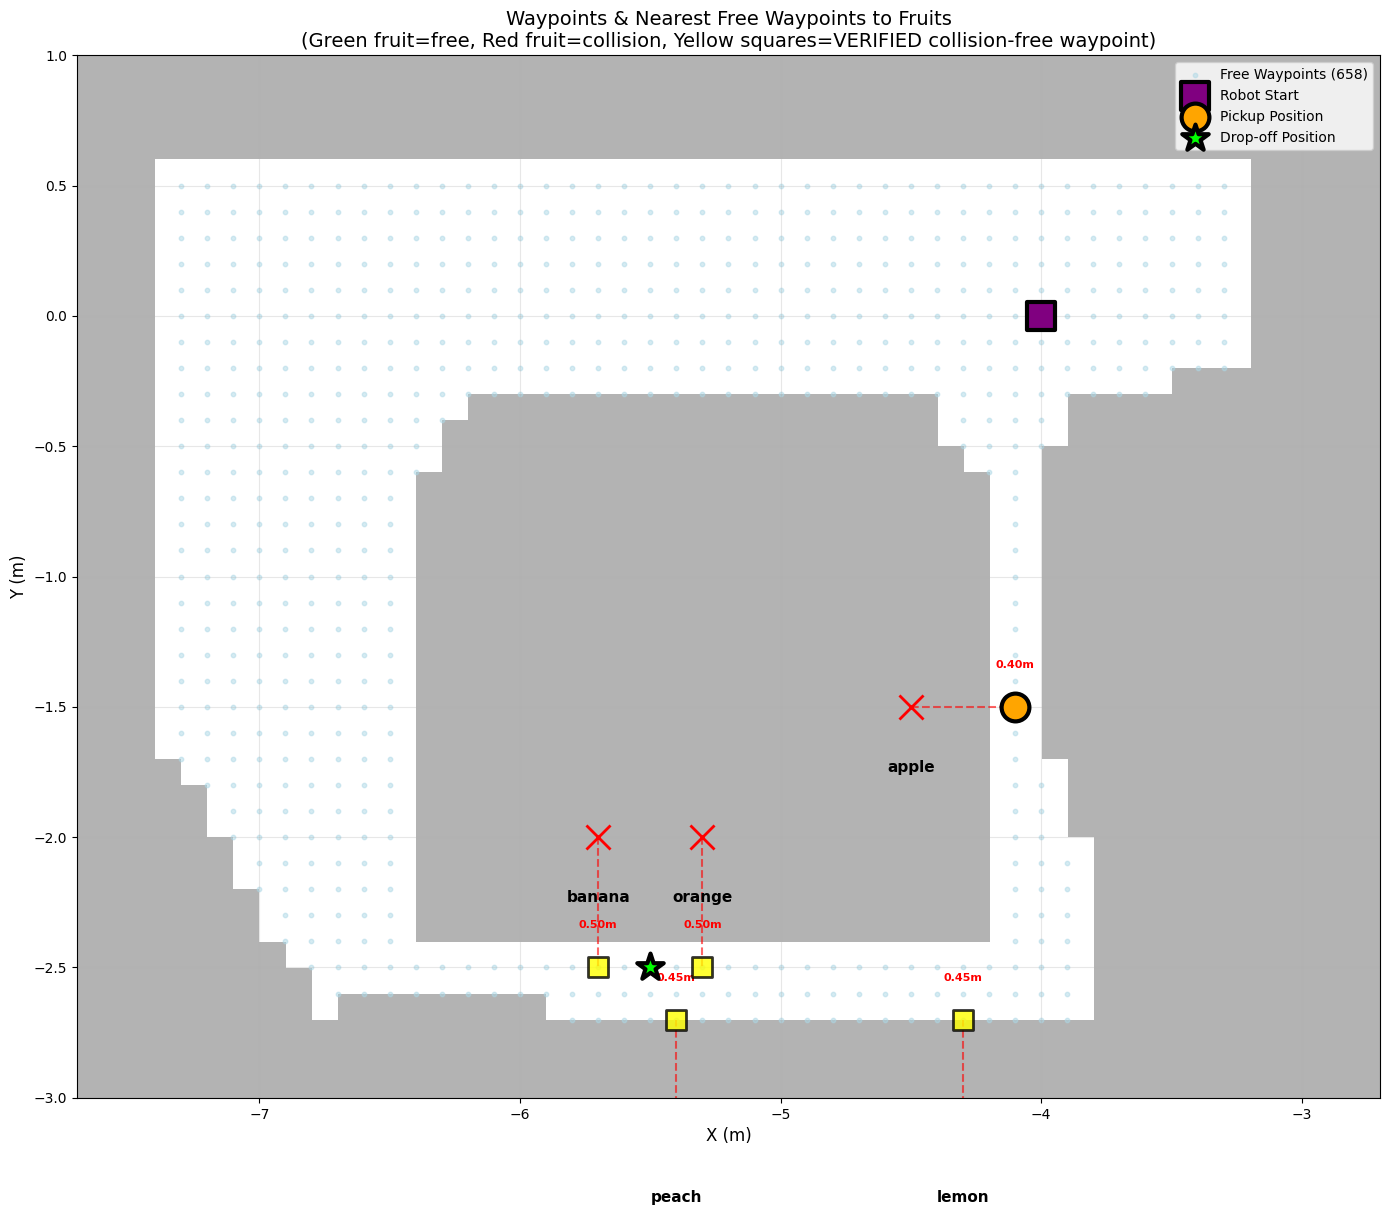


✓ Waypoint visualization complete


In [9]:
# Generate all free waypoints from the occupancy grid
free_waypoints = []

for i, x in enumerate(x_positions):
    for j, y in enumerate(y_positions):
        if occupancy_grid[j, i] == 0:  # Free space
            # Double-check with rrt.is_collision_free() to ensure consistency
            if rrt.is_collision_free(x, y):
                free_waypoints.append((x, y))

free_waypoints = np.array(free_waypoints)

print(f"Total free waypoints: {len(free_waypoints)}")
print(f"Grid dimensions: {occupancy_grid.shape}")
print(f"Total grid cells: {occupancy_grid.shape[0] * occupancy_grid.shape[1]}")
print(f"Occupied cells: {np.sum(occupancy_grid > 0)}")
print(f"Free cells (grid check): {np.sum(occupancy_grid == 0)}")
print(f"Free cells (verified): {len(free_waypoints)}")

# Find nearest free waypoints to each fruit
print("\n" + "="*60)
print("NEAREST FREE WAYPOINTS TO EACH FRUIT")
print("="*60)

from scipy.spatial import KDTree
kdtree = KDTree(free_waypoints)

fruit_nearest_waypoints = {}
for fruit_name, fruit_data in kitchen_map.items():
    fruit_pos = (fruit_data['x'], fruit_data['y'])
    
    # Check if fruit position itself is free
    is_free = rrt.is_collision_free(fruit_pos[0], fruit_pos[1])
    
    # Find nearest VERIFIED collision-free waypoint
    # Query multiple candidates to ensure we get a truly collision-free one
    k_neighbors = min(20, len(free_waypoints))
    distances, indices = kdtree.query(fruit_pos, k=k_neighbors)
    
    nearest_waypoint = None
    nearest_distance = float('inf')
    
    for dist, idx in zip(distances, indices):
        candidate = tuple(free_waypoints[idx])
        # Verify again with rrt.is_collision_free()
        if rrt.is_collision_free(candidate[0], candidate[1]):
            nearest_waypoint = candidate
            nearest_distance = dist
            break
    
    if nearest_waypoint is None:
        print(f"⚠️ WARNING: Could not find verified collision-free waypoint for {fruit_name}!")
        nearest_waypoint = tuple(free_waypoints[indices[0]])  # Fallback to first candidate
        nearest_distance = distances[0]
    
    fruit_nearest_waypoints[fruit_name] = {
        'fruit_pos': fruit_pos,
        'is_collision_free': is_free,
        'nearest_waypoint': nearest_waypoint,
        'distance': nearest_distance
    }
    
    status = "✓ FREE" if is_free else "✗ COLLISION"
    print(f"{fruit_name:10s}: {fruit_pos} [{status}]")
    print(f"           Nearest waypoint: {nearest_waypoint} (distance: {nearest_distance:.3f}m)")

print("="*60)

# Visualize all waypoints with nearest waypoints to fruits highlighted
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# Plot occupancy grid
ax.imshow(occupancy_grid, cmap='gray_r', origin='lower', 
          extent=[X_MIN, X_MAX, Y_MIN, Y_MAX], alpha=0.3, interpolation='nearest')

# Plot all free waypoints
if len(free_waypoints) > 0:
    ax.scatter(free_waypoints[:, 0], free_waypoints[:, 1], 
              s=10, c='lightblue', alpha=0.5, label=f'Free Waypoints ({len(free_waypoints)})')

# Plot all fruit positions and their nearest waypoints
for fruit_name, fruit_data in kitchen_map.items():
    x, y = fruit_data['x'], fruit_data['y']
    info = fruit_nearest_waypoints[fruit_name]
    
    # Fruit position
    color = 'green' if info['is_collision_free'] else 'red'
    marker = 'o' if info['is_collision_free'] else 'x'
    ax.scatter(x, y, s=300, c=color, marker=marker, 
              edgecolors='black', linewidth=2, zorder=5)
    ax.text(x, y-0.25, fruit_name, ha='center', fontsize=11, fontweight='bold')
    
    # Nearest waypoint - verify it's actually collision-free before plotting
    nearest_wp = info['nearest_waypoint']
    is_waypoint_free = rrt.is_collision_free(nearest_wp[0], nearest_wp[1])
    
    if is_waypoint_free:
        wp_color = 'yellow'
        ax.scatter(nearest_wp[0], nearest_wp[1], s=200, c=wp_color, marker='s', 
                  edgecolors='black', linewidth=2, zorder=5, alpha=0.8)
        
        # Draw line from fruit to nearest waypoint
        ax.plot([x, nearest_wp[0]], [y, nearest_wp[1]], 'r--', linewidth=1.5, alpha=0.6)
        ax.text(nearest_wp[0], nearest_wp[1]+0.15, f"{info['distance']:.2f}m", 
               ha='center', fontsize=8, color='red', fontweight='bold')
    else:
        # This should not happen now, but just in case
        print(f"⚠️ Waypoint {nearest_wp} for {fruit_name} is NOT collision-free!")
        ax.scatter(nearest_wp[0], nearest_wp[1], s=200, c='red', marker='x', 
                  edgecolors='black', linewidth=3, zorder=5, alpha=0.8)

# Plot robot start and targets if manipulation_result exists
try:
    manipulation_result
    has_result = True
except NameError:
    has_result = False

if has_result and manipulation_result:
    robot_start = manipulation_result['robot_start']
    ax.scatter(*robot_start, s=400, c='purple', marker='s', 
              edgecolors='black', linewidth=3, label='Robot Start', zorder=6)
    
    pickup_pos = manipulation_result['pickup_pos']
    ax.scatter(*pickup_pos, s=400, c='orange', marker='o', 
              edgecolors='black', linewidth=3, label='Pickup Position', zorder=6)
    
    dropoff_pos = manipulation_result['dropoff_pos']
    ax.scatter(*dropoff_pos, s=400, c='lime', marker='*', 
              edgecolors='black', linewidth=3, label='Drop-off Position', zorder=6)

ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xlabel('X (m)', fontsize=12)
ax.set_ylabel('Y (m)', fontsize=12)
ax.set_title('Waypoints & Nearest Free Waypoints to Fruits\n(Green fruit=free, Red fruit=collision, Yellow squares=VERIFIED collision-free waypoint)', fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print("\n✓ Waypoint visualization complete")

## Visualize the Movement

Show the start and end positions visually.

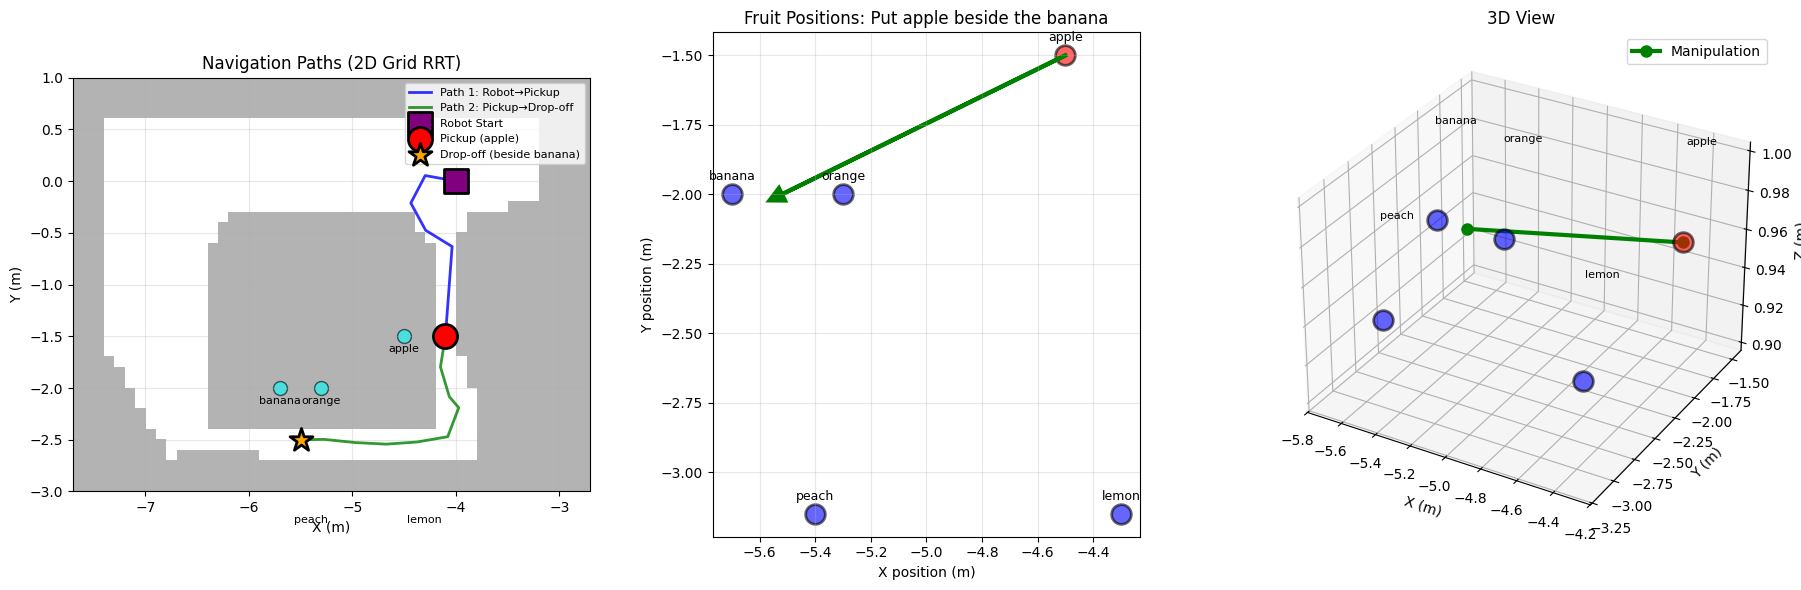

✓ Visualization complete

EXECUTION SUMMARY (2D Grid-based Planning)
1. Robot navigates from (-4.0, 0.0) to (np.float64(-4.100000000000013), np.float64(-1.4999999999999987))
   (8 waypoints via 2D grid RRT)
2. Robot picks up apple
3. Robot navigates from (np.float64(-4.100000000000013), np.float64(-1.4999999999999987)) to (np.float64(-5.500000000000008), np.float64(-2.4999999999999996))
   (10 waypoints via 2D grid RRT)
4. Robot places apple beside banana


In [10]:
if manipulation_result:
    path_to_pickup = manipulation_result.get('path_to_pickup')
    path_to_dropoff = manipulation_result.get('path_to_dropoff')
    
    if path_to_pickup is None or path_to_dropoff is None:
        print("⚠ Cannot visualize - navigation planning failed")
        if path_to_pickup is None:
            print("  - Path to pickup could not be found (collision or unreachable)")
        if path_to_dropoff is None:
            print("  - Path to drop-off could not be found (collision or unreachable)")
    else:
        robot_start = manipulation_result['robot_start']
        pickup_pos = manipulation_result['pickup_pos']
        dropoff_pos = manipulation_result['dropoff_pos']
        object_to_move = manipulation_result['object_to_move']
        target_object = manipulation_result['target_object']
        start_pos = manipulation_result['start_position']
        end_pos = manipulation_result['end_position']
        
        fig = plt.figure(figsize=(18, 6))
        
        # 1. Occupancy grid with navigation paths (2D grid-based planning)
        ax1 = fig.add_subplot(131)
        
        # Plot occupancy grid
        ax1.imshow(occupancy_grid, cmap='gray_r', origin='lower', 
                   extent=[X_MIN, X_MAX, Y_MIN, Y_MAX], alpha=0.3, interpolation='nearest')
        
        # Plot navigation paths (from 2D grid RRT)
        path1_array = np.array(path_to_pickup)
        path2_array = np.array(path_to_dropoff)
        
        ax1.plot(path1_array[:, 0], path1_array[:, 1], 'b-', linewidth=2, label='Path 1: Robot→Pickup', alpha=0.8)
        ax1.plot(path2_array[:, 0], path2_array[:, 1], 'g-', linewidth=2, label='Path 2: Pickup→Drop-off', alpha=0.8)
        
        # Mark key locations
        ax1.scatter(*robot_start, s=300, c='purple', marker='s', edgecolors='black', linewidth=2, label='Robot Start', zorder=5)
        ax1.scatter(*pickup_pos, s=300, c='red', marker='o', edgecolors='black', linewidth=2, label=f'Pickup ({object_to_move})', zorder=5)
        ax1.scatter(*dropoff_pos, s=300, c='orange', marker='*', edgecolors='black', linewidth=2, label=f'Drop-off (beside {target_object})', zorder=5)
        
        # Plot all fruits
        for fruit_name, fruit_data in kitchen_map.items():
            x, y = fruit_data['x'], fruit_data['y']
            ax1.scatter(x, y, s=100, c='cyan', alpha=0.6, edgecolors='black', linewidth=1)
            ax1.text(x, y-0.15, fruit_name, ha='center', fontsize=8)
        
        ax1.set_xlim(X_MIN, X_MAX)
        ax1.set_ylim(Y_MIN, Y_MAX)
        ax1.set_xlabel('X (m)')
        ax1.set_ylabel('Y (m)')
        ax1.set_title('Navigation Paths (2D Grid RRT)')
        ax1.legend(fontsize=8, loc='upper right')
        ax1.grid(True, alpha=0.3)
        ax1.set_aspect('equal')
        
        # 2. Top-down fruit map view
        ax2 = fig.add_subplot(132)
        
        # Plot all fruits
        for fruit_name, fruit_data in kitchen_map.items():
            x, y = fruit_data['x'], fruit_data['y']
            color = 'red' if fruit_name == object_to_move else 'blue'
            ax2.scatter(x, y, s=200, c=color, alpha=0.6, edgecolors='black', linewidth=2)
            ax2.text(x, y+0.05, fruit_name, ha='center', fontsize=9)
        
        # Plot manipulation arrow
        ax2.arrow(start_pos[0], start_pos[1], end_pos[0]-start_pos[0], end_pos[1]-start_pos[1],
                  head_width=0.05, head_length=0.05, fc='green', ec='green', linewidth=3)
        
        ax2.set_xlabel('X position (m)')
        ax2.set_ylabel('Y position (m)')
        ax2.set_title(f'Fruit Positions: {command}')
        ax2.grid(True, alpha=0.3)
        ax2.set_aspect('equal')
        
        # 3. 3D view
        ax3 = fig.add_subplot(133, projection='3d')
        
        # Plot all fruits
        for fruit_name, fruit_data in kitchen_map.items():
            x, y, z = fruit_data['x'], fruit_data['y'], fruit_data['z']
            color = 'red' if fruit_name == object_to_move else 'blue'
            ax3.scatter(x, y, z, s=200, c=color, alpha=0.6, edgecolors='black', linewidth=2)
            ax3.text(x, y, z+0.05, fruit_name, fontsize=8)
        
        # Plot manipulation movement
        ax3.plot([start_pos[0], end_pos[0]], [start_pos[1], end_pos[1]], [start_pos[2], end_pos[2]],
                 'g-', linewidth=3, marker='o', markersize=8, label='Manipulation')
        
        ax3.set_xlabel('X (m)')
        ax3.set_ylabel('Y (m)')
        ax3.set_zlabel('Z (m)')
        ax3.set_title('3D View')
        ax3.legend()
        
        plt.tight_layout()
        plt.show()
        
        print("✓ Visualization complete")
        
        # Print summary
        print("\n" + "="*60)
        print("EXECUTION SUMMARY (2D Grid-based Planning)")
        print("="*60)
        print(f"1. Robot navigates from {robot_start} to {pickup_pos}")
        print(f"   ({len(path_to_pickup)} waypoints via 2D grid RRT)")
        print(f"2. Robot picks up {object_to_move}")
        print(f"3. Robot navigates from {pickup_pos} to {dropoff_pos}")
        print(f"   ({len(path_to_dropoff)} waypoints via 2D grid RRT)")
        print(f"4. Robot places {object_to_move} beside {target_object}")
        print("="*60)
else:
    print("⚠ No manipulation result available")


## Execute Manipulation in Drake

Animate the robot following the planned path in Drake's Meshcat visualizer.


In [11]:
if manipulation_result and manipulation_result.get('path_to_pickup') and manipulation_result.get('path_to_dropoff'):
    from pydrake.all import Simulator, DiagramBuilder
    
    print("="*60)
    print("EXECUTING MANIPULATION IN DRAKE")
    print("="*60)
    
    # Get the paths
    path_to_pickup = manipulation_result['path_to_pickup']
    path_to_dropoff = manipulation_result['path_to_dropoff']
    
    # Combine paths (remove duplicate waypoint at pickup location)
    full_path = list(path_to_pickup) + list(path_to_dropoff)[1:]
    
    print(f"\nTotal navigation waypoints: {len(full_path)}")
    print(f"  Path 1 (Robot → Pickup): {len(path_to_pickup)} waypoints")
    print(f"  Path 2 (Pickup → Drop-off): {len(path_to_dropoff)} waypoints")
    
    # Create a new simulator for animation
    sim = Simulator(station)
    sim.Initialize()
    
    # Get contexts
    context = sim.get_mutable_context()
    plant_context = plant.GetMyMutableContextFromRoot(context)
    
    # Set all robot joints to zero and initialize base position
    print("\n📍 Setting robot configuration for animation...")
    
    # Get the mobile_iiwa model instance
    mobile_iiwa = plant.GetModelInstanceByName("mobile_iiwa")
    num_positions = plant.num_positions(mobile_iiwa)
    
    print(f"mobile_iiwa has {num_positions} DOFs")
    
    # Get the starting position from the path
    robot_start = manipulation_result['robot_start']
    
    # Get joint indices
    base_x_joint = plant.GetJointByName("iiwa_base_x", mobile_iiwa)
    base_y_joint = plant.GetJointByName("iiwa_base_y", mobile_iiwa)
    base_z_joint = plant.GetJointByName("iiwa_base_z", mobile_iiwa)
    
    base_x_idx = base_x_joint.position_start()
    base_y_idx = base_y_joint.position_start()
    base_z_idx = base_z_joint.position_start()
    
    # Create position array for mobile_iiwa only
    robot_positions = np.zeros(num_positions)
    robot_positions[base_x_idx] = robot_start[0]
    robot_positions[base_y_idx] = robot_start[1]
    robot_positions[base_z_idx] = 0.1  # Height
    # All arm joints default to 0 (straight configuration)
    
    # Set only the robot positions
    plant.SetPositions(plant_context, mobile_iiwa, robot_positions)
    
    print(f"✓ Robot configuration set:")
    print(f"  Base position: ({robot_start[0]:.2f}, {robot_start[1]:.2f}, 0.1)")
    print(f"  All arm joints: 0 (straight configuration)")
    
    # Start recording in Meshcat
    meshcat.StartRecording()
    print("\n🎬 Started recording animation in Meshcat")
    
    # Animate through the path
    print(f"\n🤖 Animating robot movement...")
    time_per_waypoint = 0.5  # seconds per waypoint
    
    for i, waypoint in enumerate(full_path):
        # Update robot position for this waypoint
        robot_positions = np.zeros(num_positions)
        robot_positions[base_x_idx] = waypoint[0]  # base x
        robot_positions[base_y_idx] = waypoint[1]  # base y
        robot_positions[base_z_idx] = 0.1  # Height
        # All arm joints stay at 0 (straight configuration)
        
        # Set only the robot positions (doesn't affect fruits)
        plant.SetPositions(plant_context, mobile_iiwa, robot_positions)
        
        # Advance time and publish
        sim_time = i * time_per_waypoint
        context.SetTime(sim_time)
        
        # Force diagram to publish (update visualization)
        station.ForcedPublish(context)
        
        # Print progress
        if i == 0:
            print(f"  Waypoint {i+1}/{len(full_path)}: Robot start {waypoint}")
        elif i == len(path_to_pickup) - 1:
            print(f"  Waypoint {i+1}/{len(full_path)}: Reached pickup location {waypoint}")
        elif i == len(full_path) - 1:
            print(f"  Waypoint {i+1}/{len(full_path)}: Reached drop-off location {waypoint}")
    
    # Stop recording
    meshcat.StopRecording()
    print("\n✓ Animation complete!")
    
    # Publish recording
    meshcat.PublishRecording()
    print(f"\n🎥 Animation published to Meshcat: {meshcat.web_url()}")
    print("   You can replay the animation in the Meshcat viewer")
    
    print("\n" + "="*60)
    print("ANIMATION SUMMARY")
    print("="*60)
    print(f"Total waypoints: {len(full_path)}")
    print(f"Animation duration: {len(full_path) * time_per_waypoint:.1f} seconds")
    print(f"Time per waypoint: {time_per_waypoint} seconds")
    print("="*60)
    
else:
    print("⚠ Cannot execute - no valid path available")
    print("   Run the planning cell first to generate paths")


EXECUTING MANIPULATION IN DRAKE

Total navigation waypoints: 17
  Path 1 (Robot → Pickup): 8 waypoints
  Path 2 (Pickup → Drop-off): 10 waypoints

📍 Setting robot configuration for animation...
mobile_iiwa has 10 DOFs
✓ Robot configuration set:
  Base position: (-4.00, 0.00, 0.1)
  All arm joints: 0 (straight configuration)

🎬 Started recording animation in Meshcat

🤖 Animating robot movement...
  Waypoint 1/17: Robot start (np.float64(-4.0), np.float64(0.0))
  Waypoint 8/17: Reached pickup location (np.float64(-4.100000000000013), np.float64(-1.4999999999999987))
  Waypoint 17/17: Reached drop-off location (np.float64(-5.500000000000008), np.float64(-2.4999999999999996))

✓ Animation complete!

🎥 Animation published to Meshcat: http://localhost:7001
   You can replay the animation in the Meshcat viewer

ANIMATION SUMMARY
Total waypoints: 17
Animation duration: 8.5 seconds
Time per waypoint: 0.5 seconds


## Try Other Commands

Test the system with different manipulation commands.

In [12]:
# Try different commands
test_commands = [
    "Put the lemon next to the orange",
    "Move the peach beside the banana",
]

for cmd in test_commands:
    print(f"\n{'='*60}")
    print(f"Command: {cmd}")
    print('='*60)
    
    gpt_result = query_gpt_for_manipulation(cmd, kitchen_map)
    
    if gpt_result:
        object_to_move = gpt_result['object_to_move']
        target_object = gpt_result['target_object']
        
        if object_to_move in kitchen_map and target_object in kitchen_map:
            object_pos = kitchen_map[object_to_move]['position']
            target_pos = kitchen_map[target_object]['position']
            end_pos = calculate_target_position(object_pos, target_pos, gpt_result.get('relationship', 'beside'))
            
            print(f"Object:  {object_to_move}")
            print(f"Target:  {target_object}")
            print(f"Start:   {object_pos}")
            print(f"End:     {end_pos} (calculated via 2D grid)")
            print(f"Reason:  {gpt_result.get('reasoning', 'N/A')}")
        else:
            print(f"❌ Object not found in kitchen map")
    else:
        print("❌ Failed to process command")



Command: Put the lemon next to the orange
Object:  lemon
Target:  orange
Start:   [-4.3, -3.15, 0.95]
End:     [-5.12, -2.0, 0.95] (calculated via 2D grid)
Reason:  Move lemon to be next to orange

Command: Move the peach beside the banana
Object:  peach
Target:  banana
Start:   [-5.4, -3.15, 0.95]
End:     [-5.5200000000000005, -2.0, 0.95] (calculated via 2D grid)
Reason:  Move peach to be beside banana


In [74]:
cmd = "Place apple beside the banana"

print(f"\n{'='*60}")
print(f"Command: {cmd}")
print('='*60)

gpt_result = query_gpt_for_manipulation(cmd, kitchen_map)

if gpt_result:
	object_to_move = gpt_result['object_to_move']
	target_object = gpt_result['target_object']
	
	if object_to_move in kitchen_map and target_object in kitchen_map:
		object_pos = kitchen_map[object_to_move]['position']
		target_pos = kitchen_map[target_object]['position']
		end_pos = calculate_target_position(object_pos, target_pos, gpt_result.get('relationship', 'beside'))
		
		print(f"Object:  {object_to_move}")
		print(f"Target:  {target_object}")
		print(f"Start:   {object_pos}")
		print(f"End:     {end_pos} (calculated via 2D grid)")
		print(f"Reason:  {gpt_result.get('reasoning', 'N/A')}")
	else:
		print(f"❌ Object not found in kitchen map")
else:
	print("❌ Failed to process command")



Command: Place apple beside the lemon
Object:  apple
Target:  lemon
Start:   [-4.5, -1.5, 0.95]
End:     [-4.12, -3.15, 0.95] (calculated via 2D grid)
Reason:  Move apple to be beside lemon
Object:  apple
Target:  lemon
Start:   [-4.5, -1.5, 0.95]
End:     [-4.12, -3.15, 0.95] (calculated via 2D grid)
Reason:  Move apple to be beside lemon


In [75]:
from pydrake.all import SceneGraphCollisionChecker

ix = plant.GetJointByName("iiwa_base_x").position_start()
iy = plant.GetJointByName("iiwa_base_y").position_start()
iz = plant.GetJointByName("iiwa_base_z").position_start()
j1 = plant.GetJointByName("iiwa_joint_1").position_start()

# Get initial configuration and limits
active_lo, active_hi = 3, 10
qlo = plant.GetPositionLowerLimits()
qhi = plant.GetPositionUpperLimits()
vlo = plant.GetVelocityLowerLimits()
vhi = plant.GetVelocityUpperLimits()
qlo[ix], qhi[ix] = -8, -4
qlo[iy], qhi[iy] = -4, 0
qlo[j1], qhi[j1] = -0.01, 0.01
collision_checker = SceneGraphCollisionChecker(
						model=station,
						robot_model_instances=[station.plant().GetModelInstanceByName("mobile_iiwa")],
						edge_step_size=0.01,
						env_collision_padding=0.01,
						self_collision_padding=0.01,)

INFO:drake:Allocating contexts to support implicit context parallelism 8


In [76]:
from pydrake.all import RigidTransform, RollPitchYaw

# Define target gripper pose in world frame
target_position = np.array([-4.425, -1.525, 0.925])
target_rpy = RollPitchYaw([-np.pi/12, 0, np.pi/2])
X_WG_grasp = RigidTransform(target_rpy, target_position)
print(f"Target gripper position: {target_position}")

# Define target place pose in world frame
target_position = np.array(end_pos)
target_rpy = RollPitchYaw([0, 0, 0])
X_WG_place = RigidTransform(target_rpy, target_position)
print(f"Target gripper position: {target_position}")

Target gripper position: [-4.425 -1.525  0.925]
Target gripper position: [-4.12 -3.15  0.95]


In [17]:
import sys
sys.path.append('../src')
from ik import IKSolver

q0 = plant.GetPositions(plant_context).copy()
init_guess = q0.copy()
init_guess[3:10] = 0
init_guess[0:2] = pickup_pos

ik_solver = IKSolver(
    plant=plant,
    plant_context=plant_context,
    ix=0, iy=1, iz=2, active_hi=10,
    q0=q0,
    gripper_body=plant.GetBodyByName("body"),
	pos_tol=0.015,
	theta_bound = 0.02*np.pi,
	base_tol=0.15,
)

q_grasp = ik_solver.solve(X_WG_grasp, init_guess)
print(q_grasp)
collision_checker.CheckConfigCollisionFree(q_grasp)

[-3.93462997 -1.66438482  0.1194448   1.00182775  0.3528154  -0.97047588
  1.49590457  2.96664115  0.48965783  3.0505581   0.          0.
  1.          0.          0.          0.         -4.5        -1.5
  0.95        1.          0.          0.          0.         -5.3
 -2.          0.95        1.          0.          0.          0.
 -5.7        -2.          0.95        1.          0.          0.
  0.         -5.4        -3.15        0.95        1.          0.
  0.          0.         -4.3        -3.15        0.95      ]


True

In [77]:
q0 = plant.GetPositions(plant_context).copy()
init_guess = q0.copy()
init_guess[3:10] = 0
init_guess[0:2] = pickup_pos

ik_solver = IKSolver(
    plant=plant,
    plant_context=plant_context,
    ix=0, iy=1, iz=2, active_hi=10,
    q0=q0,
    gripper_body=plant.GetBodyByName("body"),
	pos_tol=0.02,
	theta_bound = 0.02*np.pi
)

q_grasp = ik_solver.solve(X_WG_grasp, init_guess)
print(q_grasp)
collision_checker.CheckConfigCollisionFree(q_grasp)

Infeasible constraints: ['drake::multibody::PositionConstraint[1]: -3.170000 <= -2.563085 <= -3.130000']


In [18]:
q_target = np.array([-4.4004417 , -2.91778252,  0.02935388,  0.03622381,  0.03685292,
       -0.18278937, -0.80933222, -1.36926305,  1.94631227, -1.89012708,
        0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
        0.        , -4.5       , -1.5       ,  0.95      ,  1.        ,
        0.        ,  0.        ,  0.        , -5.3       , -2.        ,
        0.95      ,  1.        ,  0.        ,  0.        ,  0.        ,
       -5.7       , -2.        ,  0.95      ,  1.        ,  0.        ,
        0.        ,  0.        , -5.4       , -3.15      ,  0.95      ,
        1.        ,  0.        ,  0.        ,  0.        , -4.3       ,
       -3.15      ,  0.95      ])

In [78]:
path_to_pickup = rrt.plan(robot_start, pickup_pos)
path_to_dropoff = rrt.plan(pickup_pos, dropoff_pos)

Goal position [-4.12 -3.15  0.95] is in collision!


In [20]:
from rrt import RRTTools

q0 = plant.GetPositions(plant_context).copy()
q0[3:10] = 0.0
q0[0:2] = pickup_pos
q_upright = q0.copy()
q_upright[3:10] = 0.0
q_upright[0:2] = pickup_pos

tools = RRTTools(
        collision_checker=collision_checker,
        q_lo=qlo, q_hi=qhi,
        df_start=active_lo, df_end=active_hi,
        step_size=0.01,
        goal_threshold=0.01,
    )

rrt_path_pick = tools.plan(q_start=q0, q_goal=q_grasp, max_iterations=50_000)
rrt_path_pick = tools.shortcut_path(rrt_path_pick)
rrt_path_pick_to_upright = tools.plan(q_start=q_grasp, q_goal=q_upright, max_iterations=50_000)
rrt_path_pick_to_upright = tools.shortcut_path(rrt_path_pick_to_upright)

rrt_path_pick = [cut_path[:10] for cut_path in rrt_path_pick]
rrt_path_pick_to_upright = [cut_path[:10] for cut_path in rrt_path_pick_to_upright]


[RRT] iteration 0
[RRT] Connected in 1 iterations
[RRT] iteration 0
[RRT] Connected in 1 iterations


In [46]:
q0 = plant.GetPositions(plant_context).copy()
q_dropoff = q0.copy()
q_dropoff[0:2] = dropoff_pos
q_dropoff[3:10] = 0.0
q_upright = q_dropoff.copy()
q_upright[3:10] = 0.0
q_upright[0:2] = q_place[0:2]
rrt_path_place = tools.plan(q_start=q_dropoff, q_goal=q_place, max_iterations=50_000)
rrt_path_place_to_upright = tools.plan(q_start=q_place, q_goal=q_upright, max_iterations=50_000)
rrt_path_place = tools.shortcut_path(rrt_path_place)
rrt_path_place_to_upright = tools.shortcut_path(rrt_path_place_to_upright)
rrt_path_place = [cut_path[:10] for cut_path in rrt_path_place]
rrt_path_place_to_upright = [cut_path[:10] for cut_path in rrt_path_place_to_upright]

[RRT] iteration 0
[RRT] Connected in 1 iterations
[RRT] iteration 0
[RRT] Connected in 1 iterations


In [47]:
from motion_planning import *

In [32]:
closed = 0.0

def path_to_full_q_trajectory(path, q0, speed=0.3, start_time=0.0):
    q0 = np.asarray(q0)
    nq = len(q0)

    pts = np.array([[float(p[0]), float(p[1])] for p in path])

    times = [start_time]
    for i in range(1, len(pts)):
        dist = np.linalg.norm(pts[i] - pts[i - 1])
        dt = dist / speed if speed > 0 else 0.0
        times.append(times[-1] + dt)
    times = np.array(times)  # shape (N,)

    q_knots = []
    for xy in pts:
        q = np.zeros(10)
        q[0:2] = xy
        q_knots.append(q)
    q_knots = np.array(q_knots).T   # (nq, N)

    q_traj = PiecewisePolynomial.FirstOrderHold(times, q_knots)
    wsg_times = np.array([times[0], times[-1]])
    wsg_knots = np.array([[closed, closed]])  # shape (1, 2)

    wsg_traj = PiecewisePolynomial.FirstOrderHold(wsg_times, wsg_knots)

    return q_traj, wsg_traj

In [57]:
traj_q_to_pickup, traj_wsg_to_pickup = path_to_full_q_trajectory(path_to_pickup, q0, speed=0.3, start_time=0.0)

In [58]:
traj_q_pick, traj_wsg_pick = build_trajs_pick(rrt_path_pick, rrt_path_pick_to_upright, q_grasp[:10])

[build_trajs_pick] q_samples shape: (10, 119), T=8.750s


In [59]:
traj_q_pick.shiftRight(traj_q_to_pickup.end_time())
traj_wsg_pick.shiftRight(traj_wsg_to_pickup.end_time())

In [60]:
traj_q_to_pickup.ConcatenateInTime(traj_q_pick)
traj_wsg_to_pickup.ConcatenateInTime(traj_wsg_pick)

In [61]:
traj_q_to_dropoff, traj_wsg_to_dropoff = path_to_full_q_trajectory(path_to_dropoff, q0, speed=0.3, start_time=traj_q_to_pickup.end_time())
traj_q_to_pickup.ConcatenateInTime(traj_q_to_dropoff)
traj_wsg_to_pickup.ConcatenateInTime(traj_wsg_to_dropoff)

In [62]:
traj_q_place, traj_wsg_place = build_trajs_place(rrt_path_place, q_place[:10], traj_q_to_pickup.end_time())

[build_trajs_place] q_samples shape: (10, 70), T=43.693s


In [63]:
traj_q_to_pickup.ConcatenateInTime(traj_q_place)
traj_wsg_to_pickup.ConcatenateInTime(traj_wsg_place)

In [64]:
# Print trajectory information
print("="*60)
print("COMPLETE TRAJECTORY INFORMATION")
print("="*60)
print(f"\nTrajectory Type: {type(traj_q_to_pickup).__name__}")
print(f"Start Time: {traj_q_to_pickup.start_time():.4f}s")
print(f"End Time: {traj_q_to_pickup.end_time():.4f}s")
print(f"Total Duration: {traj_q_to_pickup.end_time() - traj_q_to_pickup.start_time():.4f}s")
print(f"Number of Rows: {traj_q_to_pickup.rows()}")

# Sample trajectory at key times
print(f"\nTrajectory Samples:")
print("-" * 60)
print(f"{'Time (s)':>10} | {'Base X':>8} | {'Base Y':>8} | {'Joint 1':>8} | {'WSG':>6}")
print("-" * 60)

sample_times = np.linspace(traj_q_to_pickup.start_time(), traj_q_to_pickup.end_time(), 20)
for t in sample_times:
    q = traj_q_to_pickup.value(t).flatten()
    wsg = traj_wsg_to_pickup.value(t).flatten()
    print(f"{t:>10.2f} | {q[0]:>8.3f} | {q[1]:>8.3f} | {q[3]:>8.3f} | {wsg[0]:>6.3f}")
print("="*60)

COMPLETE TRAJECTORY INFORMATION

Trajectory Type: PiecewisePolynomial
Start Time: 0.0000s
End Time: 43.6934s
Total Duration: 43.6934s
Number of Rows: 10

Trajectory Samples:
------------------------------------------------------------
  Time (s) |   Base X |   Base Y |  Joint 1 |    WSG
------------------------------------------------------------
      0.00 |   -4.000 |    0.000 |    0.000 |  0.000
      2.30 |   -4.064 |   -0.549 |    0.000 |  0.000
      4.60 |   -4.090 |   -1.238 |    0.000 |  0.000
      6.90 |   -4.017 |   -1.582 |    0.501 |  0.107
      9.20 |   -3.935 |   -1.664 |    1.002 |  0.107
     11.50 |   -4.000 |   -1.599 |    0.606 |  0.000
     13.80 |   -4.100 |   -1.500 |    0.000 |  0.000
     16.10 |   -4.066 |   -1.684 |    0.000 |  0.000
     18.40 |   -4.031 |   -1.912 |    0.000 |  0.000
     20.70 |   -4.008 |   -2.140 |    0.000 |  0.000
     23.00 |   -4.075 |   -2.359 |    0.000 |  0.000
     25.30 |   -4.241 |   -2.454 |    0.000 |  0.000
     27.60 |   

In [ ]:
scenario_file = os.path.abspath("../kitchen_model/real_kitchen_scenario.yaml")
kitchen_model_path = os.path.abspath("../kitchen_model")
assets_path = os.path.abspath("../assets")

with open(scenario_file, 'r') as f:
    scenario_data = f.read()

scenario_data = scenario_data.replace("{KITCHEN_MODEL_PATH}", kitchen_model_path)
scenario_data = scenario_data.replace("{ASSETS_PATH}", assets_path)

model_drivers = """
model_drivers:
  wsg: !SchunkWsgDriver {}
  mobile_iiwa: !InverseDynamicsDriver {}
"""

scenario_data_w_driver = scenario_data + model_drivers

In [56]:
command = "Put apple beside the banana"
gpt_result = query_gpt_for_manipulation(command, kitchen_map)

print("\n" + "="*60)
print("GPT RESULT - Pretty Print")
print("="*60)
print(json.dumps(gpt_result, indent=2))
print("="*60)

object_to_move       apple               
target_object        banana              
relationship         beside              
reasoning            Move apple to be beside banana
